In [1]:
# K-Means is an example of Hards Clustering , where every points belongs only to one cluster .

In [37]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs

In [151]:
X,y=make_blobs(n_samples=5000,n_features=2,centers=5,random_state=3)

In [153]:
print(X.shape)

(5000, 2)


In [155]:
# Not really needed
np.unique(y)

array([0, 1, 2, 3, 4])

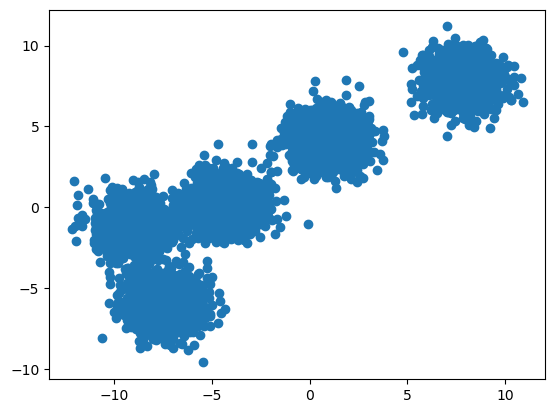

In [157]:
# Data Visualoization 
# plt.scatter(X[:,0],X[:,1],c=y)
plt.scatter(X[:,0],X[:,1])

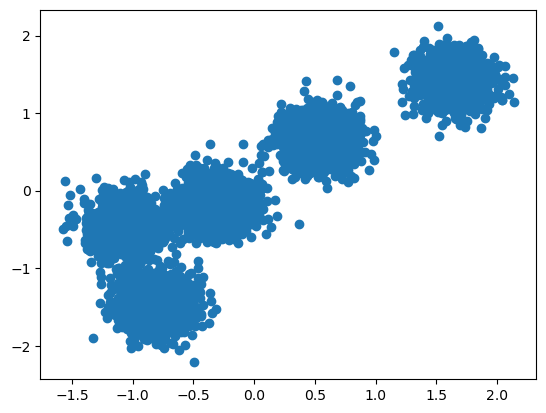

In [159]:
# Data Normalization
def normalise(X):
    u=X.mean(axis=0)
    std=X.std(axis=0)
    return (X-u)/std
    
X=normalise(X)
# Data Visualisation
plt.scatter(X[:,0],X[:,1])

In [161]:
# Init the K-centers for K clusters 
k=5
colors=['green','red','blue','yellow','orange']
n_features=2
def init(k):
    centroids={}
    for i in range(k):
        center=2*(2*np.random.random((n_features,))-1)
        centroids[i]={
            'center':center,
            'color':colors[i],
            'points':[]
        }
    return centroids



In [163]:
# Displaying the centroids
# for i in range(k):
#     print(centroids[i])
# print(centroids)

In [165]:
# Step 2a

In [167]:
def distance(p,q):
    return np.sqrt(np.sum((p-q)**2))

def assignPtsToCluster(X,centroids):
    m=X.shape[0]
    # each points will be assigned to exactly one of the clusters
    for i in range(m):
        cdist=[]
        cx=X[i]
        # find out distance of points from each centroid
        for kx in range(k):
            d=distance(centroids[kx]['center'],cx)
            cdist.append(d)
        clusterId=np.argmin(cdist)
        # assign the point to the list of points the current_cluster holds 
        centroids[clusterId]['points'].append(cx)

In [169]:
# assignPtsToCluster(X,centroids)

In [171]:
# Displaying the centroids
# for i in range(k):
#     print(centroids[i])
# centroids

In [173]:
# Step 2b -- Update the Centroids

In [175]:
def updateClusters(centroids):
    # update every centroids by taking a mean ofpoints assigned to the cluster
    for kx in range(k):
        pts=np.array(centroids[kx]['points'])
        # if a cluster has a non-zero points
        if pts.shape[0]>0:
            newCenter=pts.mean(axis=0)
            centroids[kx]['center']=newCenter
            centroids[kx]['points']=[] # clear the list for step 2a


In [178]:
def plotClusters(centroids):
    
    for kx in range(k):
        pts=np.array(centroids[kx]['points'])
        if(pts.shape[0]>0):
            plt.scatter(pts[:,0],pts[:,1],color=centroids[kx]['color'])
        # plot the Cluster Center (centroid)
        uk=centroids[kx]['center']
        plt.scatter(uk[0],uk[1],color='black',marker='*')

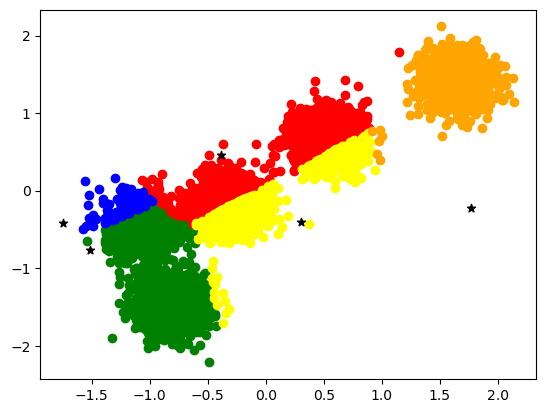

In [180]:
centroids=init(k)
assignPtsToCluster(X,centroids)
plotClusters(centroids)
# updateClusters(centroids)

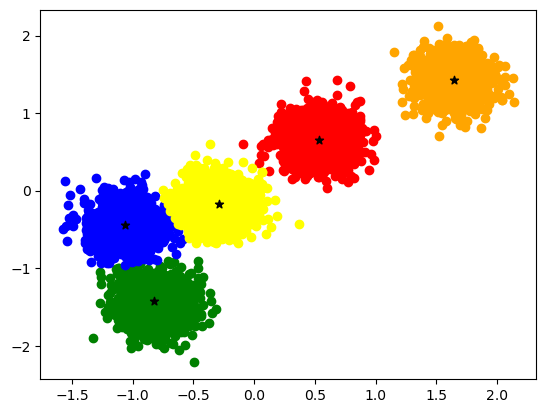

In [189]:
assignPtsToCluster(X,centroids)
plotClusters(centroids)
updateClusters(centroids)

In [193]:
# updATIONS the points successfully 